<a href="https://colab.research.google.com/github/sak-shi-collab/8_SAKSHI_D2/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 4.2 MB/s eta 0:00:00


In [2]:
pip install opencv-python

In [4]:
pip install matplotlib

Downloaded sample image to /content/sample.jpg


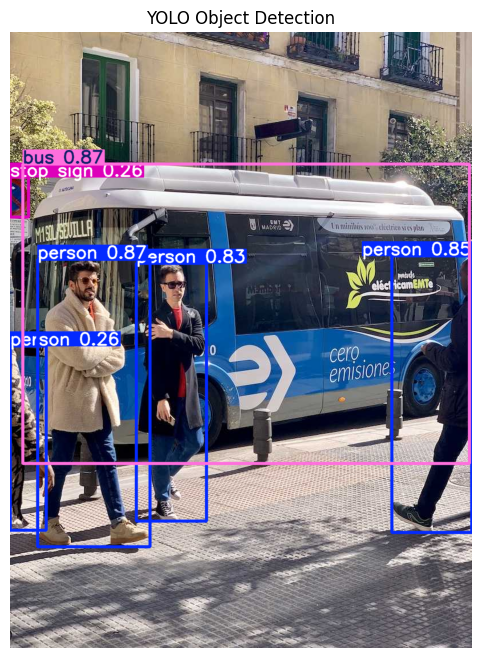

Detection completed successfully.


In [9]:
# Install (Run only once)
# pip install ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import requests

# -----------------------------
# Load YOLOv8 Pre-trained Model
# -----------------------------
model = YOLO("yolov8n.pt")

# -----------------------------
# Load Image
# -----------------------------
image_path = "/content/sample.jpg"

# Download a sample image to ensure it's not corrupted or missing
image_url = "https://ultralytics.com/images/bus.jpg" # A known good sample image
response = requests.get(image_url)
with open(image_path, "wb") as f:
    f.write(response.content)
print(f"Downloaded sample image to {image_path}")

# Explicitly load the image using OpenCV to bypass potential path issues in ultralytics
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    raise FileNotFoundError(f"OpenCV could not load the image at {image_path}. Please check the file path and integrity.")

# -----------------------------
# Perform Object Detection
# -----------------------------
# Pass the loaded image array directly to the model
results = model.predict(source=img, save=False, verbose=False)

# -----------------------------
# Display Result
# -----------------------------
result_image = results[0].plot()

plt.figure(figsize=(10,8))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO Object Detection")
plt.show()

# -----------------------------
# Save Output
# -----------------------------
cv2.imwrite("detected_output.jpg", result_image)

print("Detection completed successfully.")

In [14]:
from ultralytics import YOLO
import cv2

# Load the YOLO model
model = YOLO("yolov8n.pt")

# Input image
input_image = "/content/OIP.jpg"  # Changed to the correct path of the downloaded image

# Read the image
image = cv2.imread(input_image)

if image is None:
    raise FileNotFoundError(f"Could not find or open {input_image}")

# Run YOLO object detection
results = model(image)

# COCO class IDs:
# 0 = person
# 67 = cell phone
person_count = 0
phone_count = 0

# Draw detections
for result in results:
    boxes = result.boxes

    for box in boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        # Ignore low-confidence detections
        if confidence < 0.3:
            continue

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if class_id == 0:
            person_count += 1
            label = f"Person {confidence:.2f}"
            color = (0, 255, 0)

        elif class_id == 67:
            phone_count += 1
            label = f"Phone {confidence:.2f}"
            color = (255, 0, 0)

        else:
            continue

        # Draw bounding box
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

        # Draw label
        cv2.putText(
            image,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

# Display total counts
count_text = f"People: {person_count} | Mobile Phones: {phone_count}"

cv2.rectangle(image, (10, 10), (450, 55), (0, 0, 0), -1)

cv2.putText(
    image,
    count_text,
    (20, 42),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2
)

# Save the final image
output_image = "people_phone_detection.jpg"
cv2.imwrite(output_image, image)

print(f"People detected: {person_count}")
print(f"Mobile phones detected: {phone_count}")
print(f"Output saved as: {output_image}")


0: 640x512 3 persons, 5 cell phones, 217.3ms
Speed: 10.1ms preprocess, 217.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 512)
People detected: 2
Mobile phones detected: 3
Output saved as: people_phone_detection.jpg
